# Chapter 2: Routing

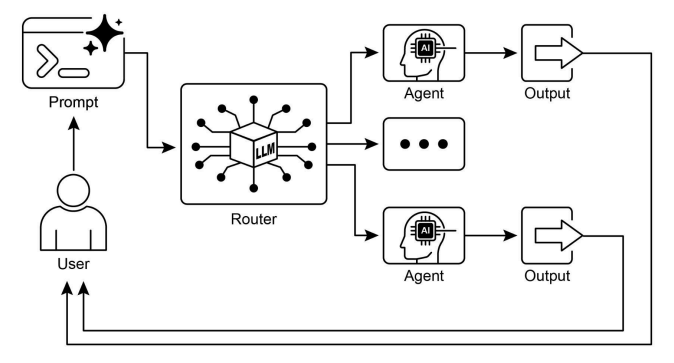

### Core Concept
- **Dynamic Decision Making**: Evaluates criteria to choose the best next step instead of a fixed, linear path.
- **Conditional Logic**: Directs info based on the situation.

### Why Use it?
- **Adaptability**: Essential for handling a wide variety of user inputs that a single process cannot handle.
- **Efficiency**: Ensures only the most relevant tools or sub-processes are used for a specific task.
- **Context Awareness**: Moves beyond rigid scripts to respond appropriately to the state of the environment.

### How it is implemented?
- **LLM-based**: The language model analyzes the input and outputs a category.
- **Embedding-based**: Converts the input into a vector to find the "closest" matching route based on meaning.
- **Rule-based**: Uses predefined "if-then" logic or keywords to make fast, deterministic decisions.
- **ML Model-based**: Uses a specialized classifier trained specifically for sorting tasks.

### Hands-on Code Example

First, ensure you have the necessary libraries installed:
```
pip install langchain langchain-community langchain-openai langgraph
```

In [1]:
import os, json
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableBranch
from dotenv import load_dotenv, find_dotenv
from IPython.display import display, Markdown

load_dotenv(find_dotenv(usecwd=True))
API_KEY  = os.environ.get("API_KEY")
BASE_URL = os.environ.get("BASE_URL")

Initialize the Language Model.

In [2]:
llm = ChatOpenAI(
    model="glm-5-turbo",
    api_key=API_KEY,
    base_url=BASE_URL,
    temperature=0
)

Define Simulated Sub-Agent Handlers.

In [3]:
def booking_handler(request: str) -> str:
    """Simulates the Booking Agent handling a request."""
    
    print("\n--- DELEGATING TO BOOKING HANDLER ---")
    return f"Booking Handler processed request: '{request}'. > Simulated booking action."

def info_handler(request: str) -> str:
    """Simulates the Info Agent handling a request."""
    
    print("\n--- DELEGATING TO INFO HANDLER ---")
    return f"Info Handler processed request: '{request}'. > Simulated information retrieval."

def unclear_handler(request: str) -> str:
    """Handles requests that couldn't be delegated."""
    
    print("\n--- HANDLING UNCLEAR REQUEST ---")
    return f"Coordinator could not delegate request: '{request}'. Please clarify."

Define Coordinator Router Chain.

In [4]:
prompt_router = ChatPromptTemplate.from_messages([
    ("system", """
        Analyze the user's request and determine which specialist handler should process it.
        
        - If the request is related to booking flights or hotels, output 'booker'.
        - For all other general information questions, output 'info'.
        - If the request is unclear or doesn't fit either category, output 'unclear'.
        
        ONLY output one word: 'booker', 'info', or 'unclear'.
    """),
    ("user", "{request}")
])

# This chain decides which handler to delegate to.
chain_router = prompt_router | llm | StrOutputParser()

Define the Delegation Logic.
- `RunnablePassthrough`: passthrough inputs unchanged or with additional keys.
- `RunnableBranch`: route based on the router chain's output.

In [5]:
branches = {
    "booker" : RunnablePassthrough.assign(output=lambda x: booking_handler(x['request']['request'])),
    "info"   : RunnablePassthrough.assign(output=lambda x: info_handler(x['request']['request'])),
    "unclear": RunnablePassthrough.assign(output=lambda x: unclear_handler(x['request']['request'])),
}

branch = RunnableBranch(
    (lambda x: x['decision'].strip() == 'booker', branches["booker"]),
    (lambda x: x['decision'].strip() == 'info', branches["info"]),
    branches["unclear"]
)

Build the agent by combining router chain and delegation branch into single runnable.

In [6]:
agent = {
    "decision": chain_router,
    "request" : RunnablePassthrough()
} | branch | (lambda x: x["output"])

Test the pipeline out.

In [7]:
from langchain_core.globals import set_debug
set_debug(False)

requests = [
    "Book me a flight to London.",
    "What is the capital of Italy?",
    "Tell me about quantum physics."
]

for request in requests:
    result = agent.invoke({"request": request})
    
    print(f"Request: {request}")
    print(f"Result : {result}")


--- DELEGATING TO BOOKING HANDLER ---
Request: Book me a flight to London.
Result : Booking Handler processed request: 'Book me a flight to London.'. > Simulated booking action.

--- DELEGATING TO INFO HANDLER ---
Request: What is the capital of Italy?
Result : Info Handler processed request: 'What is the capital of Italy?'. > Simulated information retrieval.

--- DELEGATING TO INFO HANDLER ---
Request: Tell me about quantum physics.
Result : Info Handler processed request: 'Tell me about quantum physics.'. > Simulated information retrieval.
